# Screen contacts for noise and responsivity to images
Specifically designed for EmotionTask data <br>

Meant as a way to determine which contacts should be analyzed

**Prerequisites:** <br>
Files <br>
* *montage.csv
* *iEEG.csv
* *events.csv
<br>

Code <br>
* numpy
* pandas
* matplotlib
* seaborn ... (maybe)
* scipy
* ipywidgets
* my GRID_lab_python repo (https://github.com/jtmiles/GRID_lab_python)


Contacts drawn from a montage file <br>
*All* pairs of valid contacts from the montage file are identified <br>
Bipolar rereferenced signals are processed and screened for noise <br>
ERPs are generated to compare across contacts/regions

### Imports

In [1]:
# imports
import numpy as np
import numpy.ma as ma
import pandas as pd
import os
import re
from itertools import combinations
from datetime import datetime, date, time, timedelta
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

from scipy.signal import find_peaks
# from scipy.ndimage import uniform_filter as unifilt
# from scipy.signal import coherence, find_peaks
# from scipy.signal import hilbert
# from scipy.ndimage import median_filter
# from scipy.stats import median_abs_deviation as MAD

from iEEG_utils.loading import read_data
from iEEG_utils.processing import filtering
from iEEG_utils import utils

# import ipywidgets as widgets

# instantiate a random number generator
rng = np.random.default_rng()

### notebook specific functions

In [2]:
def spike_heights(data,spike_ix,spk_win):
    '''
    Rough spike height calculation based on
    vertical distance between ID'd spike and 
    neighboring zero crossing points (nearby extrema)

    data : np.array (1D)
        preprocessed data
    spike_ix : int
        index of ID'd spikes
    spk_win : int
        number of samples before and after spike
        to search through for neighboring extrema
    '''

    # zero crossing of 1st derivative == extrema, so take "derivative"
    d_spike = np.diff(data[(spike_ix-spk_win):(spike_ix+spk_win)])
    # identified spike peak. should potentially do an explicit max search as well...
    max_ix = spk_win-1
    # find where the zero crossings occur (-/+ transition)
    xings = np.flatnonzero(np.sign(d_spike[:-1])*np.sign(d_spike[1:])<0)
    pre_xing = xings[(xings-max_ix)<0][-1]-spk_win+1 # +1 for diff
    # not all "spikes" resolve within window
    try:
        post_xing = xings[(xings-max_ix)>0][0]-spk_win+1
    except:
        # double the post_xing window
        d_spike = np.diff(data[(spike_ix-spk_win):(spike_ix+spk_win*2)])
        xings = np.flatnonzero(np.sign(d_spike[:-1])*np.sign(d_spike[1:])<0)
        post_xing = xings[(xings-max_ix)>0][0]-spk_win+1
    return (np.array([spike_ix+(pre_xing),spike_ix,spike_ix+(post_xing)]))

def plot_ERPs(ERP_mat,imgs,ERP_thresh,ixA,ixB):
    '''
    plot average ERP for each image category
    specify categories (array of strings)
    set threshold for SNR calculation
    use ixA and ixB as integer ixs for finding max/min
    '''

    if "house" in imgs.to_numpy():
        ERP_mat = ERP_mat[imgs!="house",:]
        imgs = imgs[imgs!="house"]
        
        
    img_cats = imgs.unique()
    img_cats.sort()
    fig,ax = plt.subplots(1,len(img_cats),tight_layout=True,figsize=(8,2))
    ax = ax.flatten()
    pline = np.ones((len(plot_ts),))

    # make a dict of amplitudes and array of avg ERPs
    ERP_amps = {}
    ERPs = np.zeros([len(img_cats),len(plot_ts)])
    # iterate through image categories and plot
    for ix,cat in enumerate(img_cats):
        ERP = np.nanmean(ERP_mat[imgs==cat,:],axis=0)
        ERPs[ix,:] = ERP
        max_ix = np.argmax(ERP[ixA:ixB])+ixA
        min_ix = np.argmin(ERP[ixA:ixB])+ixA
        
        ax[ix].plot(plot_ts,ERP)
        ax[ix].set_title(cat)
        ax[ix].scatter(plot_ts[max_ix],ERP[max_ix])
        ax[ix].scatter(plot_ts[min_ix],ERP[min_ix])
    
        ax[ix].fill_between(plot_ts, pline*(-ERP_thresh),
                           pline*(ERP_thresh),
                           color=[0.4,0.4,0.4,0.25])            
        
        ERP_amps[cat] = ERP[max_ix] - ERP[min_ix]
   
    # set axis maxes    
    ampval = np.max(np.abs(ERPs.flatten()))*1.125
    [ax[ix].set_ylim([-ampval,ampval]) for ix in range(len(ax))]
    [ax[ix].set_yticklabels([]) for ix in range(1,len(ax))]
    [ax[ix].plot([0,0],ax[ix].get_ylim(),"r:") for ix in range(len(ax))]
    return ERP_amps,ax

### Load data/metadata

In [3]:
# use file selection dialog to choose folder with data
fstr = read_data.select_directory()
print(fstr)

C:\Users\jmile3\OneDrive - SCH\emotional_faces_data\a5a41c\EmotionTask


In [4]:
# load each data file

montage = read_data.load_info(fstr,ftype="montage")
montage.name = montage.name.replace(" ","",regex=True)
origfs,data = read_data.load_iEEG(fstr,load_meta=True)
events = read_data.load_info(fstr,ftype="events")
data.columns = data.columns.str.replace(r"\s+", "", regex=True)

try:
    origtime = pd.to_datetime(data.time,format='%H:%M:%S.%f')
except AttributeError:
    origtime = pd.to_datetime(data.index,format='%H:%M:%S.%f')
    
origts = np.array(origtime-origtime[0])/ np.timedelta64(1, 's')

if origfs == None:
    origfs = 1/np.diff(origts).astype("float64").mean()
    print("original sampling frequency not declared, calculated as: "+str(origfs)+" Hz")

display(data.head())


,LA_2,LA_3,LA_4,LA_5,LA_15,LA_16,LC_1,LC_2,LC_3,LC_4,...,LJ_2,LO_11,LO_12,LP_2,LP_3,LP_15,LP_16,LW_14,LW_15,reearch_1
time,,,,,,,,,,,,,,,,,,,,,
11:38:03.590230,-21.891334,-37.649530,-13.576371,5.668745,-23.970075,-45.629212,15.056606,45.433044,-57.833432,-116.038173,...,-121.268553,-69.769427,-7.608373,-91.361509,-42.075236,113.427983,38.459204,12.039079,51.199873,115.104387
11:38:03.591230,-19.611425,-36.107238,-14.246933,6.406363,10.362676,-9.016553,7.076924,35.374621,-66.483676,-123.816687,...,-119.592149,-68.160080,-6.803700,-94.848429,-47.037391,106.722368,37.654530,7.009868,46.841223,146.419611
11:38:03.592230,-23.232457,-38.185979,-17.130347,2.785330,40.336776,23.840962,4.260566,32.625319,-70.037652,-128.644730,...,-121.536778,-70.171764,-10.424732,-96.055439,-46.903279,103.570729,39.062709,6.339306,46.103605,169.688096
11:38:03.593230,-30.407465,-46.836223,-26.518209,-6.669587,80.369300,69.036810,4.998183,34.234666,-69.165922,-131.259920,...,-126.431877,-77.279717,-21.287829,-93.708474,-41.672899,103.436616,41.879068,11.569686,51.199873,199.528084
11:38:03.594230,-28.127556,-46.702111,-26.451152,-8.077766,151.046485,148.498351,12.374360,41.007338,-61.052127,-128.041225,...,-121.067385,-76.407987,-23.366569,-86.198185,-35.034340,107.594098,49.858750,23.304513,61.459464,241.639348


## region selection
run once, to generate the dropdown list <br>
click and reselect as often as you want <br>
re-run the following cell after reselcting to get new data

In [5]:
# Align traces to image onsets

img_ts = origts[events.img_on_ix]

ch_list = montage.name.to_list()

# create a dropdown to choose region to analyze
all_reg = montage.region.unique()
dropdown = utils.dropdown_select(all_reg)


Dropdown(description='Choose region:', options=('l_amy', 'l_middletemporal', 'l_hip', 'l_inferiortemporal', 'l…

In [6]:
reg = dropdown.value
pairs_list = utils.find_valid_pairs(montage.loc[montage.region==reg,"name"].to_list())
print(pairs_list)

[('LA_4', 'LA_5'), ('LA_3', 'LA_4'), ('LA_2', 'LA_3')]


## signal processing

In [7]:
# parameters for signal processing
resrate = 1024
lpfreq = 300

ts,bipolar,filtwins1 = filtering.bipolar_reref(data.loc[:,pairs_list[0]], origfs,
                                               resrate, lpfreq=lpfreq,norm=None)
# time prior to (pre) and after (post) image onset
pre = -1
post = 2

t_ixs = np.array([np.where((ts>=(im_t+pre))&(ts<=(im_t+post))) for im_t in img_ts]).squeeze()

not normalizing


## noise screens

minimize signal amplitude envelope excursions <br>
minimize spike contamination <br>
If a tie-breaker is truly needed, maximize ERP signal-to-noise <br>

_more than 5% amplitude excursions seems like trouble_ <br>
_also show variance of the amplitude envelope_

Number of trials filtered: 17
Total percent of amplitude excursions: 0.77%
StDev of amplitude envelope: 1.9


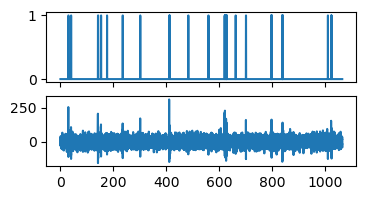

In [8]:
# identify noise artifacts using local changes in amplitude envelope
win_dur = 0.125 # seconds
norm_env = utils.envelope_noise_screen(bipolar, resrate, window_s=win_dur)

MAD_thresh = 8.0 # median absolute deviations
min_dur = 0.125 # seconds
n_samples = int(min_dur * resrate)
amp_mask = filtering.rolling_sum(np.int64(norm_env>MAD_thresh),
                                 n_samples,
                                 axis=0)>0
# see how many trials have amplitude excursions within the ERP window
pre = -1
post = 2
plot_ts = np.linspace(pre,post,t_ixs.shape[1])
ixA = np.min(np.where(plot_ts>=pre))
ixB = np.argmin(np.abs(plot_ts-post))
filt_bip = np.ma.array(bipolar,mask=amp_mask)
t_mask = filt_bip[t_ixs[:,ixA:ixB]].mask.sum(axis=1)<=16
print(f"Number of trials filtered: {sum(~t_mask)}")

print(f"Total percent of amplitude excursions: {round(100*(sum(amp_mask[t_ixs].flatten())/len(amp_mask.flatten())),2)}%")
print(f"StDev of amplitude envelope: {round(np.std(norm_env),2)}")
fig,[ax1,ax2] = plt.subplots(2,1,figsize=(4,2))
ax1.plot(ts,amp_mask)
ax1.set_xticklabels([])
ax2.plot(ts,bipolar)
plt.show()

## Finding spikes (just the small ones)

The line-length algorithm is useful for finding focal changes in signal amplitude, by simply taking the absolute difference in subsequent samples across a relatively short window. <br>

There's still the issue of calculating a threshold, however, which is particularly difficult when spikes are frequent - standard statistical methods start to fail in these cases because the amplitude distributions become so skewed. <br>

Instead, we can generate "neural-like" surrogate data segments that are based on FFT amplitude spectra, but scrambled phase spectra. Scrambling the phase and forcing an FFT-like reconstruction makes the likelihood that sharp, brief transients will be present in the surrogate data vanishingly small, but retaining the amplitude spectra retains the original signal's general amplitude distribution. <br>

Doing so means we can calculate max line-lengths of many surrogates to create a null distribution of "spike-free" line-length values for setting our threshold. <br>

We can then seek out the channel with the largest proportion of actual line-length amplitudes below the surrogate line-length distribution.

46.203856522157906 0.9991533702377076
Number of (small) spikes: 6


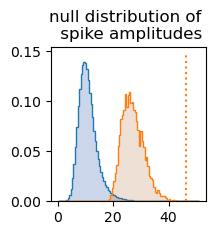

In [9]:
# number of samples to perform rolling calculation over
win = int(resrate/64)
# get null distribution from surrogate line-length maxima
null_dist = utils.spike_surrogates(bipolar, t_ixs[t_mask,ixA:ixB], 5000, win)
spikeval = null_dist.max()

# actual data segments
spike_mat = filtering.rolling_sum(np.abs(np.diff(bipolar[t_ixs])),win,axis=-1)
# amp_dist = np.max(spike_mat,axis=1)
amp_dist = spike_mat.flatten()

print(spikeval, sum(amp_dist<spikeval)/len(amp_dist))

# search for local extrema in data to find actual spikes
pks = find_peaks(bipolar, distance=int(win/2), width=[3,resrate/4])[0]
# combine the positive and negative extrema
pk_ixs = np.concat([find_peaks(-bipolar, distance=int(win/2), width=[3,resrate/4])[0],pks])
# grab indices of spikes that are *BELOW* amplitude threshold
spikes = filtering.rolling_sum(np.abs(np.diff(np.concat([(bipolar[1],),bipolar]))),win,axis=0) 
spike_ixs = np.arange(len(bipolar))[(~amp_mask*(spikes>spikeval)).astype(bool)]
# get spike peaks
ix_filt = spike_ixs[np.isin(spike_ixs,pk_ixs)]
print(f"Number of (small) spikes: {len(ix_filt)}")
      
bins = np.linspace(0,1.1*max([null_dist.max(),np.percentile(spike_mat.flatten(),99.9)]),100)

fig,ax = plt.subplots(figsize=(2,2))
ax.hist(amp_dist,bins=bins, density=True,
        histtype="stepfilled",edgecolor="C0",facecolor=[0,0.2,0.6,0.2])
ax.hist(null_dist,bins=bins, density=True,
        histtype="stepfilled",edgecolor="C1",facecolor=[0.7,0.4,0.2,0.2])
ax.plot([spikeval,spikeval],ax.get_ylim(),":",color="C1")
ax.set_title("null distribution of \n spike amplitudes",horizontalalignment="center")
plt.show()


20.596648577447414


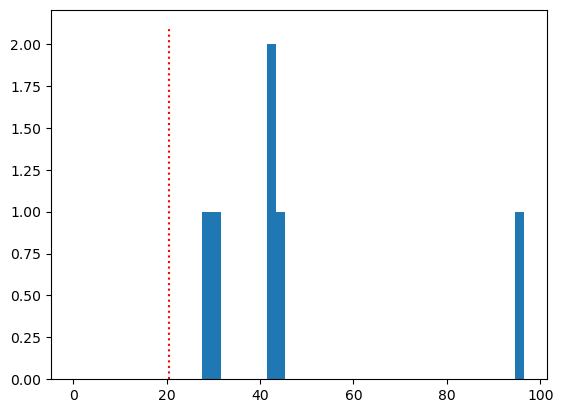

In [11]:
all_spikes = np.zeros((len(ix_filt),))
spk_win = win*4
for ix,s in enumerate(ix_filt):
    spike_ixs = spike_heights(bipolar, s, spk_win)
    all_spikes[ix] = np.abs(np.diff(bipolar[spike_ixs])).mean()

fig, ax = plt.subplots()
bins = np.linspace(0,all_spikes.max(),50)
ax.hist(all_spikes, bins=bins)
# compare "spikes" to clean st dev of signal
# not really a fair comparison 
# SDs are calculated by sample
# spikes occur over several
cleanSD = np.nanstd(bipolar[(~amp_mask*(spikes<spikeval)).astype(bool)])
print(cleanSD)
ax.plot([cleanSD,cleanSD],ax.get_ylim(),"r:")

plt.show()

[ 859613  859613  857603 1047483  857603  859613  857603  859613  860827]


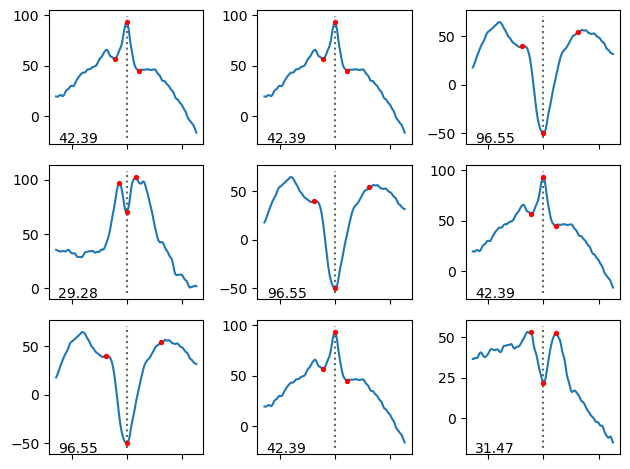

In [12]:
randspikes = rng.choice(ix_filt[all_spikes>cleanSD],size=(9,))
print(randspikes)
fig,ax = plt.subplots(3,3,tight_layout=True)
ax = ax.flatten()
spk_win = 64
p_spks = np.arange(-spk_win,spk_win)
for ix,s in enumerate(randspikes):
    # curr_spike = bipolar[(s-64):(s+64)]
    # d_spike = np.concat([(0,),np.diff(curr_spike)])
    # max_ix = 64
    # # find where the zero crossings occur (-/+ transition)
    # xings = np.flatnonzero(np.sign(d_spike[:-1])*np.sign(d_spike[1:])<0)
    # pre_xing = xings[(xings-max_ix)<0][-1]
    # post_xing = xings[(xings-max_ix)>0][0]
    spike_ixs = spike_heights(bipolar,s,spk_win) #[pre_xing,max_ix,post_xing]
    ax[ix].plot(p_spks,bipolar[(s-spk_win):(s+spk_win)])
    ax[ix].scatter(spike_ixs-s,bipolar[spike_ixs],s=8,c="r",zorder=2)
    ax[ix].set_xticklabels([])
    ax[ix].plot([0,0],ax[ix].get_ylim(),linestyle=":",color=[0.4,0.4,0.4],zorder=0)
    ax[ix].text(-spk_win+2,min(ax[ix].get_ylim())+1,f"{np.round(np.abs(np.diff(bipolar[spike_ixs])).mean(),2)}")

plt.show()

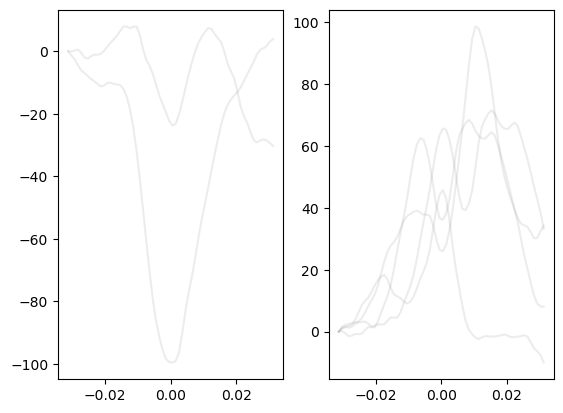

In [13]:
fig,[ax1,ax2] = plt.subplots(1,2)
xs = np.linspace(-1/32,1/32,64)
for x in ix_filt:
    if (bipolar[x]-bipolar[x-32])<0:
        ax1.plot(xs,bipolar[x-32:x+32]-bipolar[x-32], color=[0.3,0.3,0.3,0.1])
    if (bipolar[x]-bipolar[x-32])>0:
        ax2.plot(xs,bipolar[x-32:x+32]-bipolar[x-32], color=[0.3,0.3,0.3,0.1])
        

6.239883024211762


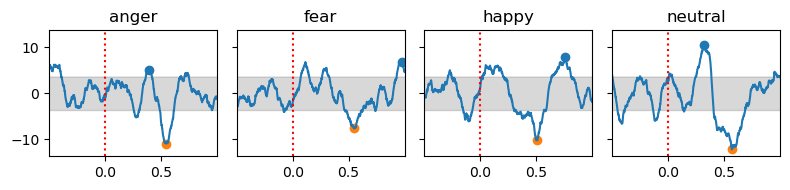

In [23]:
# hm, currently just masking high-amp trials (not spikes)
# continue only using (low-amp) spikes to arbitrate between channels
# but not filter from data?

ERP_tfilt = bipolar[t_ixs[t_mask,:]]
ERP_thresh = np.nanstd(np.nanmean(ERP_tfilt[:,(plot_ts<-0.5)],axis=0))*2.5
# reset ixA to be slightly after image start
ixA = np.argmin(np.abs(plot_ts-0.05))
ixB = np.argmin(np.abs(plot_ts-1))
ERP_amps,ERP_ax = plot_ERPs(ERP_tfilt, events.img_category[t_mask], ERP_thresh, ixA, ixB)
img_cats = np.array(["anger","fear","neutral","happy","house"])

print(max(abs(np.array([ERP_amps[cat] for cat in img_cats[img_cats!="house"]]))/ERP_thresh))
[ERP_ax[ix].set_xlim([-0.5,1.0]) for ix in range(len(ERP_ax))]
[ERP_ax[ix].set_xticks([-0,0.5], labels=["0.0","0.5"]) for ix in range(len(ERP_ax))]
plt.show()

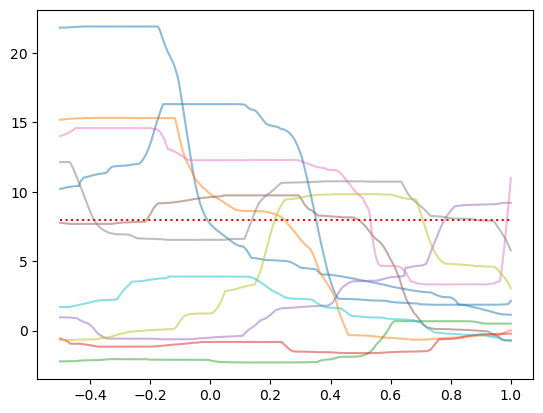

In [16]:
temp = norm_env[t_ixs[~t_mask,:]]
filtwin = (plot_ts>-0.5)&(plot_ts<=1)
plt.plot(plot_ts[filtwin],temp[:,filtwin].T,alpha=0.5)
plt.plot([-0.5,1],[8,8],"r:")
plt.show()

0 0
5 0
0 32
0 0


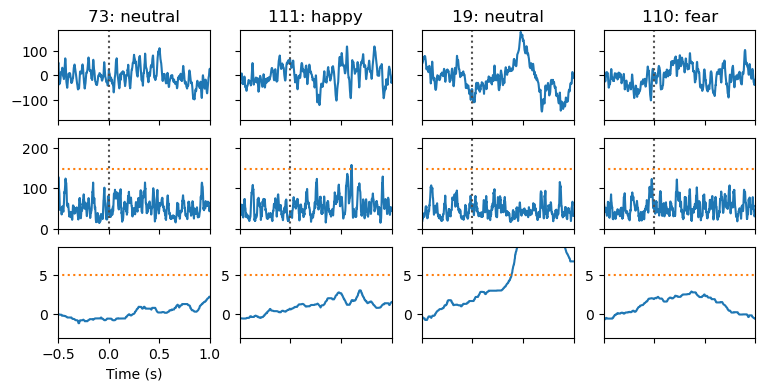

[ 0  0  5  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  4  0  0  0  0  0  0  0  0  0
  0  0  0  2  0  0  0  8  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0
  0  0  0  0  0  0  7  0  0  0  0  0  0  4  0  5  0  0  0 16  4  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  3  0  0  2  0  0  0  0  0  0  0  0  0 12 24  0  1 15  0  0  0  0
  0  0  0  0  0  2  0  0  0  0  0  0  0  0  0  0  0  0  0  6  0  0  0 14
  0  0  0  0  0  0  0  0  0  0  7  0  0 18  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
0
0.00046145494028230187


In [75]:

ERP_mat = bipolar[t_ixs]
# ylims = np.array([-1,1])*np.abs(np.percentile(bipolar[t_ixs].flatten(),99.9))
ylims = np.array([-1,1])*min([np.abs(filt_bip).max(),filt_bip.std()*5])
plot_ts = np.linspace(pre,post,t_ixs.shape[1])

ixA = np.min(np.where(plot_ts>=-0.5))
ixB = np.argmin(np.abs(plot_ts-1))
spike_mat = filtering.rolling_sum(np.abs(np.diff(bipolar[t_ixs])),win,axis=-1)

above_spikes = filtering.rolling_sum(np.int64(spike_mat[:,ixA:ixB]>spikeval),win*2,axis=1)
above_amps = filtering.rolling_sum(np.int64(norm_env[t_ixs[:,ixA:ixB]]>5),win*2,axis=1)

fig,ax = plt.subplots(3,4,figsize=(9,4))

for p in range(4):
    
    rand_t = rng.integers(low=0, high=ERP_mat.shape[0])

    ax[0,p].plot(plot_ts, ERP_mat[rand_t,:])
    p_ixs = np.isin(t_ixs[rand_t,:],ix_filt)
    ax[0,p].scatter(plot_ts[p_ixs],bipolar[t_ixs[rand_t,:][p_ixs]],s=16,c="r")
    ax[0,p].set_xticklabels("")
    ax[1,p].plot(plot_ts[1:], spike_mat[rand_t,:])
    ax[1,p].set_xticklabels("")
    ax[2,p].plot(plot_ts,norm_env[t_ixs[rand_t,:]])
    ax[2,p].plot([-1,2],[5,5],":",c="C1")
    ax[2,p].set_ylim([-3,8.5])
    ax[0,p].set_title(f"{rand_t}: {events.img_category[rand_t]}")
    
    [ax[ix,p].set_xlim([-0.5,1]) for ix in range(3)]
    print(np.max(above_spikes[rand_t]), np.max(above_amps[rand_t]))
    
[ax[0,ix].set_ylim(ylims) for ix in range(4)]
[ax[0,ix].set_yticklabels([]) for ix in range(1,4)]
[ax[1,ix].set_ylim([0,1.5*spikeval]) for ix in range(4)]
[ax[1,ix].set_yticklabels([]) for ix in range(1,4)]
[ax[-1,ix].set_xticklabels([]) for ix in range(1,4)]
ax[-1,0].set_xlabel("Time (s)")

[ax[0,ix].plot([0,0],ax[0,ix].get_ylim(),":",c=[0.3,0.3,0.3]) for ix in range(4)]
[ax[1,ix].plot([-1,2],[spikeval,spikeval],":",c="C1") for ix in range(4)]
[ax[1,ix].plot([0,0],ax[1,ix].get_ylim(),":",c=[0.3,0.3,0.3]) for ix in range(4)]

plt.show()

print(np.sum(spike_mat[:,ixA:ixB]>spikeval,axis=-1))
print(np.sum(np.max(above_spikes,axis=1)==win*2))
print(np.sum(spike_mat[:,ixA:ixB]>spikeval,axis=(-1,0))/len(spike_mat[:,ixA:ixB].flatten()))

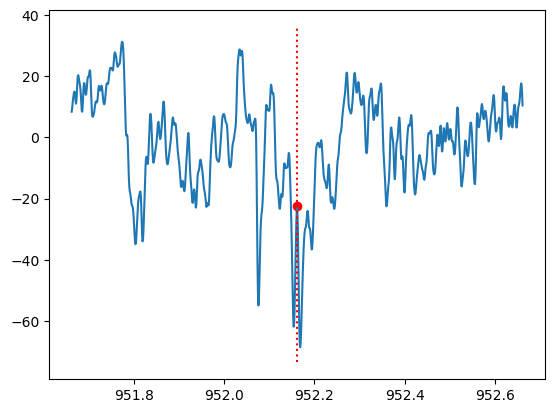

[975013]


In [311]:
t_win = np.arange(975013 -int(resrate/2),975013 +int(resrate/2)+1)
plt.plot(ts[t_win],bipolar[t_win])
plt.plot(ts[t_win[0]]+[0.5,0.5],plt.ylim(),"r:")
test = ix_filt[np.isin(ix_filt,t_win)]
plt.scatter(ts[test],bipolar[test],color="r")
plt.show()
print(ix_filt[np.isin(ix_filt,t_win)])

(-25.0, 25.0)

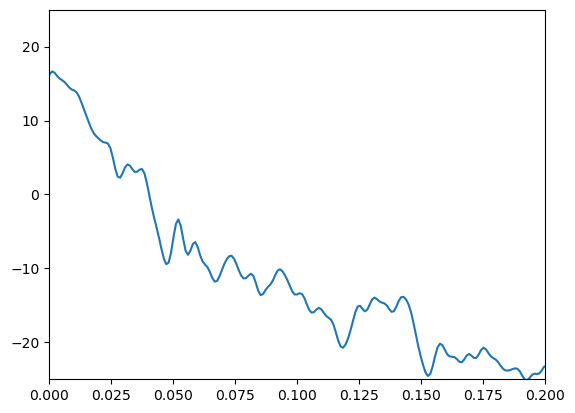

In [70]:
plt.plot(plot_ts,bipolar[t_ixs[233,:]])
plt.xlim([0,0.2])
plt.ylim([-25,25])

In [419]:
(amp_mask*spikes<spikeval).astype(bool).sum()

np.int64(1076652)

In [517]:

# search for local extrema in data

pks = find_peaks(bipolar, width=[3,resrate/4])[0]
pk_ixs = np.concat([find_peaks(-bipolar, width=[3,resrate/4])[0],pks])
ix_mask = np.arange(len(bipolar))[(~amp_mask*spikes>spikeval).astype(bool)]

(0.0, 10.0)

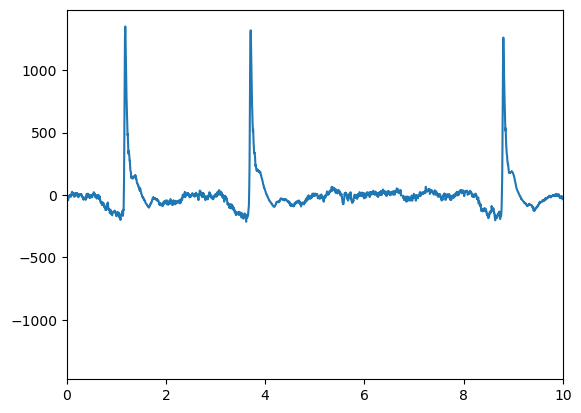

In [521]:
test = np.copy(bipolar)
test[ix_mask] = np.nan
plt.plot(ts,test)
plt.xlim([0,10])

In [549]:
spike_ixs

array([      5,      25,      48, ..., 1089508, 1089515, 1089528])

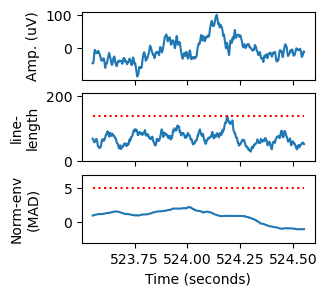

In [644]:
pwin = int(resrate)
randix = rng.integers(low=0,high=len(bipolar)-win)
p_ixs = np.arange(randix,randix+pwin)

fig,[ax1,ax2,ax3] = plt.subplots(3,1,figsize=(3,3))


ax1.plot(ts[p_ixs],bipolar[p_ixs])
ax1.set_xticklabels([])
noise = np.copy(bipolar)
noise[spikes<spikeval] = np.nan
# ax1.scatter(ts[p_ixs][(spikes[p_ixs]>spikeval)],noise[p_ixs][(spikes[p_ixs]>spikeval)],
#             c="r",s=1,zorder=2,marker="o")

# search for local extrema in data
pks = find_peaks(bipolar, distance=3, threshold=0.5, width=[3,resrate/4])[0]
pk_ixs = np.concat([find_peaks(-bipolar, distance=3, threshold=0.5, width=[3,resrate/4])[0],pks])
# grab indices of spikes that are below amplitude threshold
spike_ixs = np.arange(len(spikes))[(~amp_mask*(spikes>spikeval)).astype(bool)]
# look for spike peaks
ix_filt = np.isin(p_ixs,pk_ixs[np.isin(pk_ixs,spike_ixs)])
ax1.scatter(ts[p_ixs[ix_filt]],bipolar[p_ixs[ix_filt]],s=16,c="r")

ax1.set_ylabel("Amplitude (uV)")
ax1.set_xlabel("Time (seconds)")

ax2.plot(ts[p_ixs],spikes[p_ixs])
ax2.plot([min(ts[p_ixs]),max(ts[p_ixs])],[spikeval,spikeval],"r:")
# ax1.set_ylim([-150,150])
ax2.set_ylim([0,spikeval*1.5])
# ax1.set_xlim([fig_t0,fig_t0+1])
# ax2.set_xlim([fig_t0,fig_t0+1])
ax2.set_xticklabels([])

ax3.plot(ts[p_ixs],norm_env[p_ixs])
ax3.plot([min(ts[p_ixs]),max(ts[p_ixs])],[5,5],"r:")
ax3.set_ylim([-3,7])

ax1.set_ylabel("Amp. (uV)")
ax2.set_ylabel("line-\nlength")
ax3.set_ylabel("Norm-env\n(MAD)")
ax3.set_xlabel("Time (seconds)")

fig.align_ylabels([ax1,ax2,ax3])
plt.show()

(-25.0, 250.0)

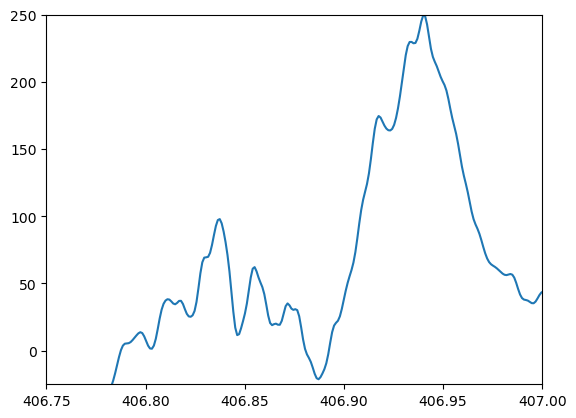

In [630]:
plt.plot(ts,bipolar)
plt.xlim([406.75,407])
plt.ylim([-25, 250])

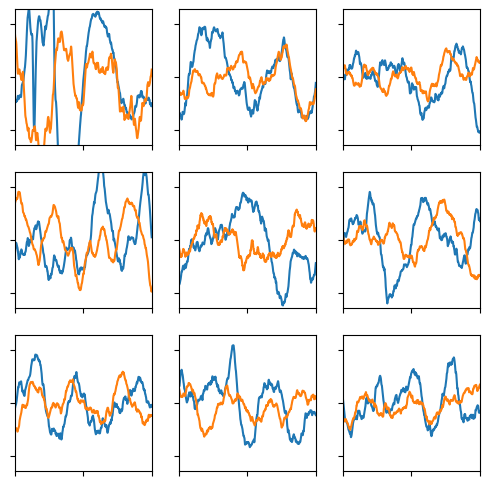

[  0   0   0   0   0  81   0   0  29   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0  20   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0  64   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0  73  14   0   0   0   0   0   0   0   0
   0   0   0   0 190   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  40   0   0   0   0   0]
0
0.0013870792616720955


In [35]:
ERP_mat = bipolar[t_ixs]
ylims = np.array([-1,1])*np.abs(np.percentile(bipolar[t_ixs].flatten(),99.5))
plot_ts = np.linspace(pre,post,t_ixs.shape[1])

ixA = np.min(np.where(plot_ts>=-0.5))
ixB = np.argmin(np.abs(plot_ts-1))
spike_mat = filtering.rolling_sum(np.abs(np.diff(bipolar[t_ixs])),win,axis=-1)

above_spikes = filtering.rolling_sum(np.int64(spike_mat[:,ixA:ixB]>spikeval),win*2,axis=1)
above_amps = filtering.rolling_sum(np.int64(norm_env[t_ixs[:,ixA:ixB]]>5),win*2,axis=1)

fig,ax = plt.subplots(3,3,figsize=(6,6))

for p in range(3):
    for q in range(3):
    
        rand_t = rng.integers(low=0, high=ERP_mat.shape[0])
    
        ax[q,p].plot(plot_ts, ERP_mat[rand_t,:])
        surrogate_t = utils.phase_scramble(ERP_mat[rand_t,:],axes=0)
        ax[q,p].plot(plot_ts, surrogate_t)
        
        ax[q,p].set_xticklabels("")
        # ax[q,p].set_title(f"{rand_t}: {events.img_category[rand_t]}")
        ax[q,p].set_xlim([0,1])
        ax[q,p].set_yticklabels([])
        ax[q,p].set_xticklabels([])
        ax[q,p].set_ylim(ylims)
plt.show()

print(np.sum(spike_mat[:,ixA:ixB]>spikeval,axis=-1))
print(np.sum(np.max(above_spikes,axis=1)==win*2))
print(np.sum(spike_mat[:,ixA:ixB]>spikeval,axis=(-1,0))/len(spike_mat[:,ixA:ixB].flatten()))

In [29]:
def spike_surrogates(signal, ix_mat, n_samps, win, seed=None):
  """
  Estimating spike thresholds using line-length calculations across
  surrogate data segments.

  Parameters
  ----------
  signal : 1D ndarray
      Pre-bandpassed signal (single channel).
  ix_mat : 2D array
      Array of timestamp indices that will be used to reshape signal.
      (N segments x M samples per segment - note: N is often trials)
  n_samps : int
      Number of times to randomly sample (rows) from ix_mat.
      Sets the number of entries into the null distribution.
  win : int
      number of samples to take for rolling sum in line-length calculation

  Returns
  -------

  null_dist : 1D array
      Distribution of surrogate segment line-length maxima
  """

  rng = np.random.default_rng(seed)

  # create new matrix of data segments for calculating null distribution
  # IMPORTANT: expecting the *0-th* dimension of ix_mat to be N segments 
  randixs = rng.integers(low=0, high=ix_mat.shape[0],size=[n_samps,])
  print(signal[ix_mat[randixs,:]].shape)
  # calculate the surrogate samples (n_samps x M samples per segment)
  surrogates = utils.phase_scramble(signal[ix_mat[randixs,:]], axes=-1)
  print(surrogates.shape)
  # calculate null line-lengths (across each surrogate segment) 
  null_spikes = filtering.rolling_sum(np.abs(np.diff(surrogates,axis=-1)),win,axis=-1)
  print(null_spikes.shape)
  # return the *max* of each individual line-length calculation from each segment
  return np.max(null_spikes,axis=-1)


173.2347426905852 173.2347426905852 0.9006539672202323


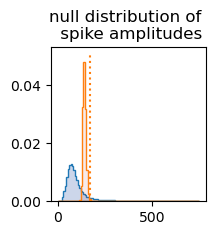

In [690]:
# generate a null distribution of spike values for thresholding

# subsample segments of data around image presentations
ixA = np.argmin(np.abs(plot_ts))
ixB = np.argmin(np.abs(plot_ts-1))
# segdur = 1
# winsamps = int(segdur*resrate)
samps = 10000
# filtixs = np.arange(0,len(bipolar))[~amp_mask]
randixs = rng.integers(low=0,high=t_ixs.shape[0], size=[samps,])
# randrange = np.array([range(ix,ix+winsamps) for ix in randixs])


# generate surrogate neural data from segment fft amplitudes with scrambled phases
surrogates = phase_scramble(bipolar[t_ixs[randixs,ixA:ixB]], axes=1)
# line-length calculation
win = int(resrate/16)
null_spikes = filtering.rolling_sum(np.abs(np.diff(surrogates)),win)
# find null "spike" value for each surrogate, average across segments
null_dist = np.max(null_spikes,axis=1)
# at this point, could just add both axes above for max
# spikeval = np.percentile(null_dist,99.5)
spikeval = max(null_dist)
# actual data segments
spike_mat = filtering.rolling_sum(np.abs(np.diff(bipolar[t_ixs])),win,axis=-1)
# amp_dist = np.max(spike_mat,axis=1)
amp_dist = spike_mat.flatten()
filt_spikes = spike_mat>spikeval

print(spikeval, np.max(null_dist), sum(amp_dist<spikeval)/len(amp_dist))

bins = np.linspace(0,1.1*max([null_dist.max(),np.percentile(spike_mat.flatten(),99.9)]),100)
fig,ax = plt.subplots(figsize=(2,2))
ax.hist(amp_dist,bins=bins, density=True,
        histtype="stepfilled",edgecolor="C0",facecolor=[0,0.2,0.6,0.2])
ax.hist(null_dist,bins=bins, density=True,
        histtype="stepfilled",edgecolor="C1",facecolor=[0.7,0.2,0.2,0.1])
ax.plot([spikeval,spikeval],ax.get_ylim(),":",color="C1")
ax.set_title("null distribution of \n spike amplitudes",horizontalalignment="center")
plt.show()

In [264]:
def dropdown_select( names, label="Choose region:",default=None):
    """
    Create and display an interactive dropdown widget in a Jupyter notebook.

    Parameters
    ----------
    names : iterable of str
        The items to show in the dropdown.
    label : str, optional
        Label shown next to the dropdown.
    default : str or None, optional
        Default selected value (must be in names).

    Returns
    -------
    ipywidgets.Dropdown
        The created dropdown widget.
    """
    names = list(names)

    if default is not None and default not in names:
        raise ValueError("default must be one of the provided names")

    dropdown = widgets.Dropdown(
        options=names,
        value=default if default is not None else names[0],
        description=label,
        disabled=False,
    )

    display(dropdown)
    return dropdown

def phase_scramble(x, axes=None, seed=None, real_output=True):
    """
    Phase-scramble data along specified FFT axes.

    Parameters
    ----------
    x : ndarray
        Input array (any dimensionality).
    axes : int or tuple of int, optional
        Axes over which to compute the FFT.
        Default (None) scrambles across all axes.
    seed : int or None
        RNG seed for reproducibility.
    real_output : bool
        If True, return only the real component.

    Returns
    -------
    x_scrambled : ndarray
        Phase-scrambled array with same shape as x.
    """
    rng = np.random.default_rng(seed)

    
    if axes is not None and not isinstance(axes, (tuple, list)):
        axes = (axes,)

    # FFT along selected axes
    fft_x = np.fft.fftn(x, axes=axes)

    magnitude = np.abs(fft_x)

    # Random phase with same shape in Fourier space
    random_phase = rng.uniform(-np.pi, np.pi, size=fft_x.shape)

    # Recombine magnitude + randomized phase
    fft_scrambled = magnitude * np.exp(1j * random_phase)

    # Inverse FFT
    x_scrambled = np.fft.ifftn(fft_scrambled, axes=axes)

    if real_output:
        x_scrambled = np.real(x_scrambled)

    return x_scrambled

def envelope_noise_screen(signal, srate, window_s=1.0, MAD_thresh=5.0, min_duration_s=0.25):
    """
    Envelope-based noise detector using robust statistics.

    Parameters
    ----------
    signal : 1D ndarray
        Pre-bandpassed signal (single channel).
    srate : float
        Sampling rate (Hz).
    window_s : float
        Window (seconds) for rolling envelope median.
    z_thresh : float
        Robust z-score threshold.
    min_duration_s : float
        Minimum duration (seconds) above threshold.

    Returns
    -------
    noise_mask : 1D boolean ndarray
        True where signal is flagged as noisy.
    z_env : 1D ndarray
        Robust z-scored envelope statistic.
    """

    # get signal envelope
    env = np.abs(hilbert(signal))

    # take its rolling median
    win_samples = int(window_s * srate)
    if win_samples < 1:
        raise ValueError("window_s too small")
    env_med = median_filter(env, size=win_samples, mode="nearest")

    # calculate the robust baseline
    baseline = np.median(env_med)
    scale = MAD(env_med)
    if scale == 0:
        scale = np.finfo(float).eps

    z_env = (env_med - baseline) / scale

    # threshold based on MAD
    above = z_env > MAD_thresh

    # --- 5. Enforce minimum duration (boolean logic only) ---
    min_samples = int(min_duration_s * srate)
    noise_mask = filtering.rolling_sum(np.int64(above),win_samples,axis=0)>=min_samples

    return noise_mask, z_env

def spike_noise_screen(bipolar, srate, t_ixs, win, amp_mask, spikepct=99):
    """
    find spikes and noise in image-aligned matrix of neural data

    spikes are calculated with a line-length algorithm and thresholding
    calculated using phase-scrambled surrogate neural data sampling

    noise is calculated with a simple (high) standard deviation cutoff
    
    Parameters
    ----------
    bipolar : 1d np.array
        bipolar rereferenced data (calculated w/ bipolar_reref)
    t_ixs : 2d integer array (shape = n trials x n samples)
        indices to grab from bipolar to align data to image presentation
    win : integer
        number of samples to use for spike sums with the line-length algorithm
    ampstd : float, int (defaults to 5)
        number of standard deviations to set amplitude threshold at (should be high-ish)
    spikepct : float, int (defaults to 99)
        percentile of surrogate (null) distribution to set spike threshold at

    Returns
    ----------
    noise : 2d boolean array (shape = shape of t_ixs)
        boolean "mask" of where spike and noise criteria are met 
        
    
    """
    ERP_mat = bipolar[t_ixs]
    # do an amplitude screen for trials with noise
    pctscreen = 100*(sum(amp_mask)/len(amp_mask))
    # only use trials not screened out (high amplitude) for determining spike thresholds
    keep_trials = np.sum(amp_mask[t_ixs], axis=-1) == 0
    if (sum(keep_trials)>=(t_ixs.shape[0]/2)) | (pctscreen > 0.3):
        print(f"screening {sum(~keep_trials)} trials and {pctscreen} % of data")
    
    spikes = filtering.rolling_sum(np.abs(np.diff(bipolar)),win) 
    # generate null spikes distribution
    rand_ERP = phase_scramble(ERP_mat[keep_trials,:], axes=-1)
    rand_spikes = filtering.rolling_sum(np.abs(np.diff(rand_ERP,axis=-1)),win,axis=-1)
    spikeval = np.percentile(rand_spikes.flatten(),spikepct)
    
    # boolean "mask" of spike noises
    return spike_mat > spikeval, spikeval

def plot_ERPs(ERP_mat,img_cats,ERP_thresh,ixA,ixB):
    '''
    plot average ERP for each image category
    specify categories (array of strings)
    set threshold for SNR calculation
    use ixA and ixB as integer ixs for finding max/min
    '''

    fig,ax = plt.subplots(1,len(img_cats),tight_layout=True,figsize=(8,2))
    ax = ax.flatten()
    pline = np.ones((len(plot_ts),))

    # make a dict of amplitudes and array of avg ERPs
    ERP_amps = {}
    ERPs = np.zeros([len(img_cats),len(plot_ts)])
    # iterate through image categories and plot
    for ix,cat in enumerate(img_cats):
        ERP = np.nanmean(ERP_mat[events.img_category==cat,:],axis=0)
        ERPs[ix,:] = ERP
        max_ix = np.argmax(ERP[ixA:ixB])+ixA
        min_ix = np.argmin(ERP[ixA:ixB])+ixA
        
        ax[ix].plot(plot_ts,ERP)
        ax[ix].set_title(cat)
        ax[ix].scatter(plot_ts[max_ix],ERP[max_ix])
        ax[ix].scatter(plot_ts[min_ix],ERP[min_ix])
    
        ax[ix].fill_between(plot_ts, pline*(-thresh),
                           pline*(thresh),
                           color=[0.4,0.4,0.4,0.25])            
        
        ERP_amps[cat] = ERP[max_ix] - ERP[min_ix]
   
    # set axis maxes    
    ampval = np.max(np.abs(ERPs.flatten()))*1.125
    [ax[ix].set_ylim([-ampval,ampval]) for ix in range(len(ax))]
    [ax[ix].set_yticklabels([]) for ix in range(1,len(ax))]
    [ax[ix].plot([0,0],ax[ix].get_ylim(),"r:") for ix in range(len(ax))]
    return ERP_amps
    

In [715]:
test = find_peaks(bipolar[t_ixs[39,:]])
other_test = np.where(spikes[t_ixs[39,:]]>spikeval)
print(test)
print(other_test)
print(np.isin(other_test,test[0]))
print(len(np.isin(other_test,test[0])[0]), len(test[0]), len(other_test[0]))

(array([  21,   36,   56,   65,   85,  105,  126,  147,  168,  197,  216,
        225,  238,  269,  295,  304,  327,  351,  358,  372,  389,  410,
        440,  456,  475,  494,  574,  579,  595,  624,  643,  666,  685,
        693,  708,  726,  757,  767,  775,  783,  790,  809,  841,  866,
        882,  892,  908,  916,  936,  950,  958,  974,  986, 1005, 1011,
       1027, 1039, 1048, 1081, 1092, 1101, 1116, 1129, 1152, 1198, 1213,
       1227, 1254, 1271, 1290, 1305, 1315, 1346, 1367, 1393, 1425, 1453,
       1477, 1504, 1529, 1544, 1552, 1576, 1586, 1609, 1623, 1630, 1651,
       1667, 1679, 1712, 1721, 1731, 1739, 1755, 1777, 1800, 1812, 1834,
       1845, 1869, 1885, 1901, 1916, 1921, 1931, 1941, 1957, 1973, 1981,
       2019, 2034, 2051, 2067, 2082, 2105, 2112, 2130, 2158, 2175, 2197,
       2228, 2238, 2255, 2269, 2274, 2283, 2293, 2318, 2333, 2352, 2361,
       2374, 2392, 2411, 2430, 2438, 2454, 2478, 2500, 2522, 2542, 2561,
       2577, 2586, 2593, 2609, 2683, 2712, 2740, 2

Text(0.5, 0, 'Time (seconds)')

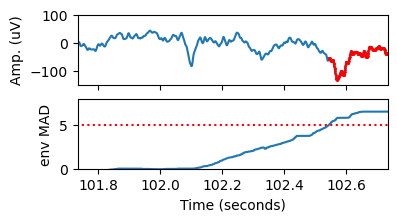

In [634]:
fig_t0 = ts[t_ixs[29,:]].min()
fig_t1 = ts[t_ixs[29,:]].max()

fig,[ax1,ax2] = plt.subplots(2,1,figsize=(4,2))
spikes = filtering.rolling_sum(np.abs(np.diff(bipolar)),win,axis=-1)

ax1.plot(ts,bipolar)
ax1.set_xticklabels([])
noise = np.copy(bipolar)
noise[norm_env<5] = np.nan
ax1.scatter(ts[(norm_env>5)],noise[(norm_env>5)],c="r",s=1,zorder=2,marker="o")
ax.set_ylabel("Amplitude (uV)")
ax.set_xlabel("Time (seconds)")

ax2.plot(ts,norm_env)
ax2.plot([0,max(ts)],[8,9],"r:")
ax2.plot([0,max(ts)],[5,5],"r:")
ax1.set_ylim([-150,100])
ax2.set_ylim([0,8])
ax1.set_xlim([fig_t0,fig_t0+1])
ax2.set_xlim([fig_t0,fig_t0+1])

ax1.set_ylabel("Amp. (uV)")
ax2.set_ylabel("env MAD")
ax2.set_xlabel("Time (seconds)")

In [505]:
trial_filt = ~np.logical_or(above_spikes.max(axis=1)>=(win*2), above_amps.max(axis=1)>=(win*2))
print(sum(trial_filt))

224


4.127169849427623


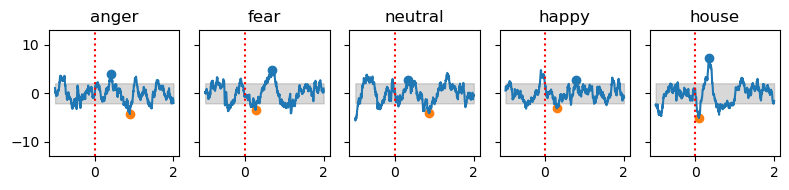

In [344]:
img_cats = np.array(["anger","fear","neutral","happy","house"])
ampval = max(ylims)
fig,ax = plt.subplots(1,len(img_cats),tight_layout=True,figsize=(8,2))
ax = ax.flatten()
pline = np.ones((len(plot_ts),))
thresh = np.nanstd(np.nanmean(ERP_mat[:,plot_ts<-0.5],axis=0))*2.5

# reset ixA to be slightly after image start
ixA = np.argmin(np.abs(plot_ts-0.05))

ERP_amps = {}
ERPs = np.zeros([len(img_cats),len(plot_ts)])
for ix,cat in enumerate(img_cats):
    ERP = np.nanmean(ERP_mat[events.img_category==cat,:],axis=0)
    ERPs[ix,:] = ERP
    max_ix = np.argmax(ERP[ixA:ixB])+ixA
    min_ix = np.argmin(ERP[ixA:ixB])+ixA
    
    ax[ix].plot(plot_ts,ERP)
    ax[ix].set_title(cat)
    ax[ix].set_ylim([-ampval/2.5,ampval/2.5])
    ax[ix].plot([0,0],ax[ix].get_ylim(),"r:")
    ax[ix].scatter(plot_ts[max_ix],ERP[max_ix])
    ax[ix].scatter(plot_ts[min_ix],ERP[min_ix])

    ax[ix].fill_between(plot_ts, pline*(-thresh),
                       pline*(thresh),
                       color=[0.4,0.4,0.4,0.25])
    if ix>0:
        ax[ix].set_yticklabels([])
    
    ERP_amps[cat] = ERP[max_ix] - ERP[min_ix]

print(abs(max([ERP_amps[cat] for cat in img_cats[img_cats!="house"]])/np.mean(np.std(ERPs[:,plot_ts<-0.5].flatten()))))

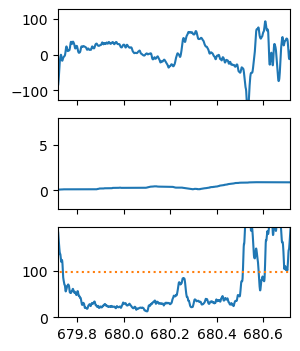

In [175]:

dt = 1
test_ts = np.linspace(1/resrate,1,winsamps)
t0 = rng.choice(ts[ts<ts.max()])

fig, ax = plt.subplots(3,1,figsize = (3,4))
axes = ax.flatten()
axes[0].plot(ts, bipolar)
axes[0].set_ylim(np.array([-1,1])*np.percentile(bipolar,99))
axes[1].plot(ts, norm_env)
axes[1].set_ylim([-2, 8])
spikes = filtering.rolling_sum(np.abs(np.diff(bipolar)),win) 
axes[2].plot(ts[1:],spikes)
axes[2].plot([min(ts),max(ts)], [spikeval,spikeval],":")
axes[2].set_ylim([0,spikeval*2])
[axes[ix].set_xlim([t0,t0+dt]) for ix in range(len(axes))]
[axes[ix].set_xticklabels("") for ix in range(len(axes)-1)]

plt.show()

In [35]:

ts,bipolar,filtwins1 = filtering.bipolar_reref(data.loc[:,pairs_list[0]], origfs,
                                                     resrate, lpfreq=lpfreq,
                                                     norm=None)
win = int(resrate/32)
ERP_mat = bipolar[t_ixs]
spikes = filtering.rolling_sum(np.abs(np.diff(bipolar)),win) 
amp_mask,_ = envelope_noise_screen(bipolar, resrate, window_s=0.5, MAD_thresh=8.0, min_duration_s=0.250)
spike_mask, spikeval = spike_noise_screen(bipolar, resrate, t_ixs, win, amp_mask, spikepct=99.9)

noise = np.logical_or(spike_mask,amp_mask[t_ixs])  
n_out = np.sum(noise,axis=-1)


not normalizing
screening 12 trials and 0.6274230498120301 % of data


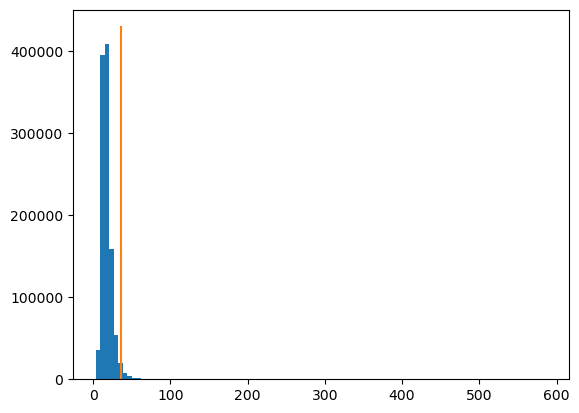

In [36]:
plt.hist(spikes, bins=np.linspace(min(spikes),max(spikes),100))
plt.plot([spikeval,spikeval],plt.ylim())
plt.show()

36.53586316162967
58
58


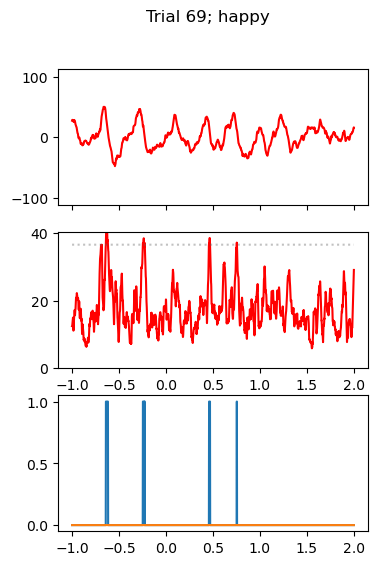

In [41]:
# testing some spike detection
rand_t = rng.integers(low=0, high=ERP_mat.shape[0])
plot_ts = np.linspace(pre,post,t_ixs.shape[1])
ampval = 5*np.nanstd(bipolar)

fig,[ax1,ax2,ax3] = plt.subplots(3,1,figsize=(4,6))
if n_out[rand_t] > win:
  c = "r"
else:
  c = "k"

ax1.plot(plot_ts,ERP_mat[rand_t,:],c=c)
ax1.set_ylim(np.array([-1,1])*ampval)
ax1.set_xticklabels([])
ax2.plot(plot_ts, spikes[t_ixs[rand_t,:]],c=c)
ax2.plot(plot_ts, np.ones((len(plot_ts),1))*[-spikeval, spikeval],":",c=[0.4,0.4,0.4,0.4])
ax2.set_ylim(np.array([0,1.1])*spikeval)
ax1.set_xticklabels([])
print(spikeval)
print(sum(spike_mask[rand_t,:]))
print(n_out[rand_t])
ax3.plot(plot_ts, spike_mask[rand_t,:])
ax3.plot(plot_ts, amp_mask[t_ixs[rand_t,:]])
plt.suptitle("Trial "+str(rand_t)+"; "+events.img_category[rand_t])

plt.show()

1075 2047
not normalizing
55 52 6994
7.153031178272935
not normalizing
154 136 12725
4.775670076528853
not normalizing
236 234 60652
7.177597508413536


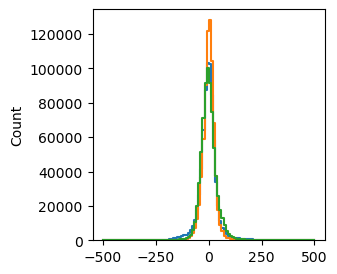

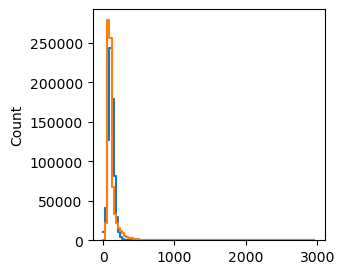

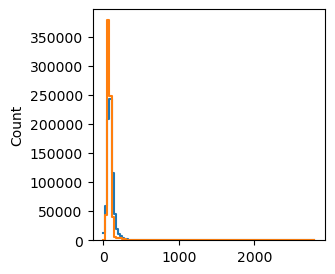

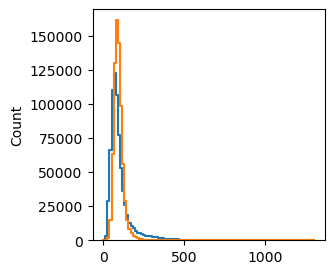

In [8]:
# bipolar rereference a pair

# try comparing line-length distributions
# look at above 80th pctile from flattened spike_mat

img_cats = np.array(["anger","fear","neutral","happy","house"])
plot_ts = np.linspace(pre,post,t_ixs.shape[1])
ixA = np.argmin(np.abs(plot_ts-0.05))
ixB = np.argmin(np.abs(plot_ts-1))
print(ixA, ixB)

fig, ax1 = plt.subplots(figsize=(3,3))

for pair in pairs_list:

    ts,bipolar,filtwins1 = filtering.bipolar_reref(data.loc[:,pair], origfs,
                                                     resrate, lpfreq=lpfreq,
                                                     norm=None)
    
    # shape into matrix with pre and post image on periods
    ERP_mat = bipolar[t_ixs]
    # "line-length" approximation (abs change in amps) for spike detection
    ####
    #### NOTE:
    #### Not really sure how to pick window length yet, and whether there
    #### needs to be a short and long window for wide and narrow spikes...
    ####
    win = int(resrate/16)
    spikes = filtering.rolling_sum(np.abs(np.diff(bipolar)),win)
    # reshape spikes to same size as ERP_mat
    spike_mat = spikes[t_ixs]
    # generate null spikes distribution
    rand_ERP = phase_scramble(ERP_mat, axes=-1)
    rand_spikes = filtering.rolling_sum(np.abs(np.diff(rand_ERP,axis=-1)),win,axis=-1)
    noise = spike_mat>np.percentile(rand_spikes[:,1:].flatten(),99)

    # # compare the upper ends of the spike and absolute amplitude distributions
    # spike_high = ma.masked_less(spike_mat,np.percentile(spike_mat.flatten(),80))
    # amp_high = ma.masked_less(np.abs(ERP_mat),np.percentile(np.abs(ERP_mat.flatten()),80))
    
    sns.histplot(data=ERP_mat.flatten(),
                 bins=np.linspace(-500,500,101),
                 ax=ax1,element='step',fill=False)
    
    binmax = max([spike_mat.flatten().max(),rand_spikes.flatten().max()])
    fig, ax2 = plt.subplots(figsize=(3,3))
    
    sns.histplot(data=spike_mat.flatten(),
                 bins=np.linspace(0,binmax,101),
                 ax=ax2,element='step',fill=False)
    
    sns.histplot(data=rand_spikes.flatten(),
                 bins=np.linspace(0,binmax,101),
                 ax=ax2,element='step',fill=False)
    
    # # boolean array of places where spikes are 2.5x stdv
    # spikethresh = filtering.zscore(spike_mat)>2.5
    # spikeval = np.nanstd(spike_mat.flatten())*2.5
    # # boolean array of places where amps > 2.5x stdv
    # ampthresh = np.abs(filtering.zscore(ERP_mat))>2.5
    # ampval = np.nanstd(ERP_mat.flatten())*2.5
    # # additional overriding criteria
    # overrides = (spikethresh>4) + (ampthresh>4)
    # # some boolean arithmetic on criteria matrices
    # noise = overrides+(ampthresh*spikethresh) > 0

    noise = spike_mat>np.percentile(rand_spikes[:,1:].flatten(),99)
    n_out = np.sum(noise,axis=-1)
    
    print(sum(n_out>0), sum(n_out>16), sum(noise.flatten()))

    ERP_amps = {}
    ERPs = np.zeros([len(img_cats),len(plot_ts)])
    for ix,cat in enumerate(img_cats):
        ERP = np.nanmean(ERP_mat[events.img_category==cat,:],axis=0)
        ERPs[ix,:] = ERP
        max_ix = np.argmax(ERP[ixA:ixB])+ixA
        min_ix = np.argmin(ERP[ixA:ixB])+ixA
        
        ERP_amps[cat] = ERP[max_ix] - ERP[min_ix]
    
    print(abs(max([ERP_amps[cat] for cat in img_cats[img_cats!="house"]])/np.mean(np.std(ERPs[:,plot_ts<-0.5].flatten()))))

    
    # print(n_out)


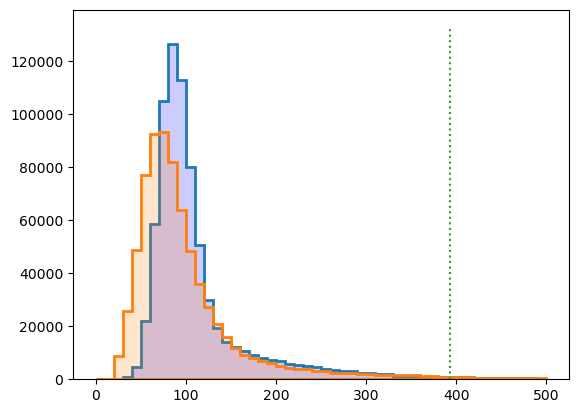

[249.5775038  393.3970537  447.78921822]


In [214]:
plt.hist(rand_spikes[:,1:].flatten(), bins=np.linspace(0,500,51),histtype="stepfilled",
         edgecolor="C0", linewidth=2, facecolor=[0,0,1,0.2])
plt.hist(spike_mat[:,1:].flatten(), bins=np.linspace(0,500,51),histtype="stepfilled",
         edgecolor="C1", linewidth=2, facecolor=[1,0.5,0,0.2])
randcut = np.percentile(rand_spikes[:,1:].flatten(),99)
plt.plot(randcut*np.array([1,1]), plt.ylim(),":")
plt.show()

print(np.percentile(rand_spikes[:,1:].flatten(),[95,99,99.5]))


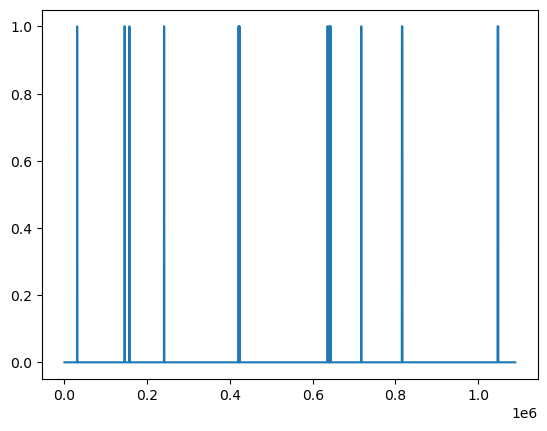

In [9]:
amp_mask,_ = envelope_noise_screen(bipolar, resrate, window_s=1, MAD_thresh=8.0, min_duration_s=0.25)
plt.plot(amp_mask)

screening 178 trials and 4.884923490366541 % of data
177.38395604350532


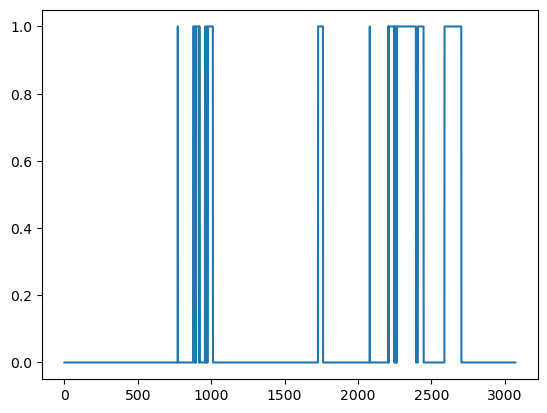

In [453]:
spike_mask, spikeval = spike_noise_screen(bipolar, resrate, t_ixs, win, amp_mask, spikepct=99.5)
print(spikeval)
np.sum(spike_mask,axis=1)
plt.plot(spike_mask[rand_t,:])

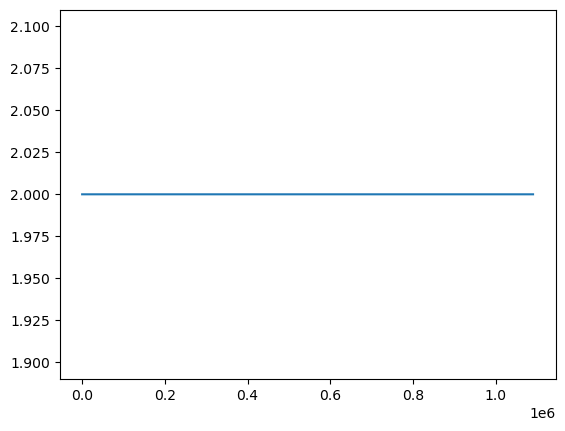

In [513]:
plt.plot(np.sum(filtwins1,axis=1))

In [509]:
np.percentile(spikes[np.sum(filtwins1[1:,:],axis=1)>1],99)

np.float64(338.9332020124334)

147.4995138680687
521
521


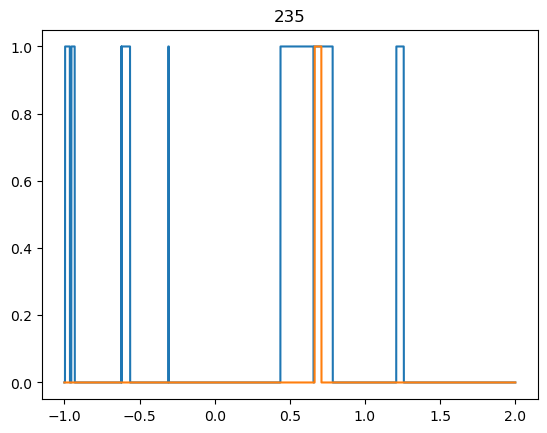

In [492]:
rand_t = rng.integers(low=0, high=ERP_mat.shape[0])
print(spikeval)
print(sum(spike_mask[rand_t,:]))
print(n_out[rand_t])
plt.plot(plot_ts, spike_mask[rand_t,:])
plt.plot(plot_ts, amp_mask[t_ixs[rand_t,:]])
plt.title(rand_t)
plt.show()

not normalizing
383.1574706272141
57 55 7545
7.153031178272935


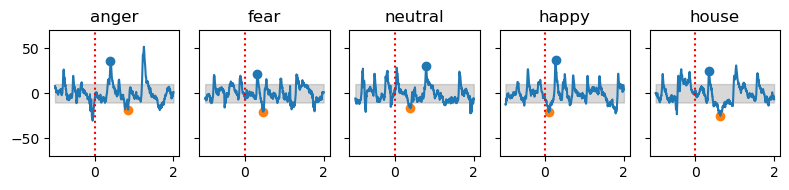

In [152]:

ts,bipolar,filtwins1 = filtering.bipolar_reref(data.loc[:,pairs_list[0]], origfs,
                                                     resrate, lpfreq=lpfreq,
                                                     norm=None)

spikes = filtering.rolling_sum(np.abs(np.diff(bipolar)),win)
ERP_mat = bipolar[t_ixs]
ampthresh = np.nanstd(ERP_mat.flatten())*5
ampscreen = filtering.rolling_sum(np.int64(ERP_mat>ampthresh),win,axis=1)

spike_mat = spikes[t_ixs]
win = int(resrate/16)

# generate null spikes distribution
rand_ERP = phase_scramble(ERP_mat, axes=-1)
rand_spikes = filtering.rolling_sum(np.abs(np.diff(rand_ERP,axis=-1)),win,axis=-1)
spikeval = np.percentile(rand_spikes[:,1:].flatten(),99)
print(spikeval)

# # boolean array of places where spikes are 2.5x stdv
# spikethresh = filtering.zscore(spike_mat)>2.5
# spikeval = np.nanstd(spike_mat.flatten())*2.5
# # boolean array of places where amps > 2.5x stdv
# ampthresh = np.abs(filtering.zscore(ERP_mat))>2.5
ampval = np.nanstd(ERP_mat.flatten())*2.5
# # additional overriding criteria
# overrides = (spikethresh>4) + (ampthresh>4)
# # some boolean arithmetic on criteria matrices
# noise = overrides+(ampthresh*spikethresh) > 0

noise = np.logical_or(spike_mat>np.percentile(rand_spikes[:,1:].flatten(),99),np.int64(ampscreen>(win/2)))  
n_out = np.sum(noise,axis=-1)
print(sum(n_out>0), sum(n_out>16), sum(noise.flatten()))

fig,ax = plt.subplots(1,len(img_cats),tight_layout=True,figsize=(8,2))
ax = ax.flatten()
pline = np.ones((len(plot_ts),))
thresh = np.nanstd(np.nanmean(ERP_mat[:,plot_ts<-0.5],axis=0))*2.5

ERP_amps = {}
ERPs = np.zeros([len(img_cats),len(plot_ts)])
for ix,cat in enumerate(img_cats):
    ERP = np.nanmean(ERP_mat[events.img_category==cat,:],axis=0)
    ERPs[ix,:] = ERP
    max_ix = np.argmax(ERP[ixA:ixB])+ixA
    min_ix = np.argmin(ERP[ixA:ixB])+ixA
    
    ax[ix].plot(plot_ts,ERP)
    ax[ix].set_title(cat)
    ax[ix].set_ylim([-ampval/2.5,ampval/2.5])
    ax[ix].plot([0,0],ax[ix].get_ylim(),"r:")
    ax[ix].scatter(plot_ts[max_ix],ERP[max_ix])
    ax[ix].scatter(plot_ts[min_ix],ERP[min_ix])

    ax[ix].fill_between(plot_ts, pline*(-thresh),
                       pline*(thresh),
                       color=[0.4,0.4,0.4,0.25])
    if ix>0:
        ax[ix].set_yticklabels([])
    
    ERP_amps[cat] = ERP[max_ix] - ERP[min_ix]

print(abs(max([ERP_amps[cat] for cat in img_cats[img_cats!="house"]])/np.mean(np.std(ERPs[:,plot_ts<-0.5].flatten()))))


[0 0 0 ... 0 0 0]


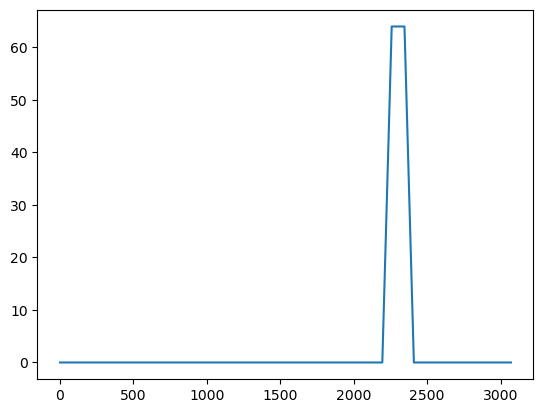

In [93]:
print(np.int64(test[4,:]))
plt.plot(filtering.rolling_sum(np.int64(test[4,:]),64,axis=0))

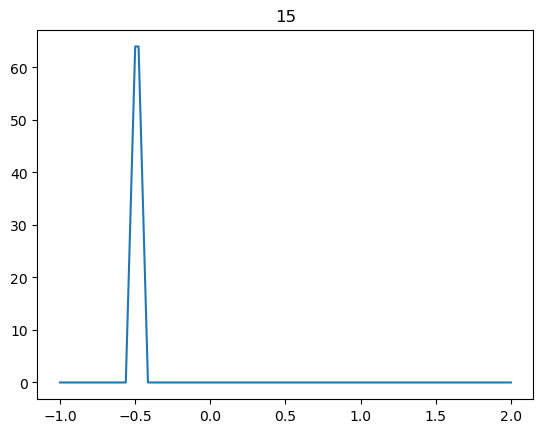

In [146]:
ampthresh = np.nanstd(ERP_mat.flatten())*5
ampscreen = filtering.rolling_sum(np.int64(ERP_mat>ampthresh),win,axis=1)
rand_t = rng.integers(low=0, high=ERP_mat.shape[0])

plt.plot(plot_ts, test[rand_t,:])
plt.title(rand_t)
plt.show()

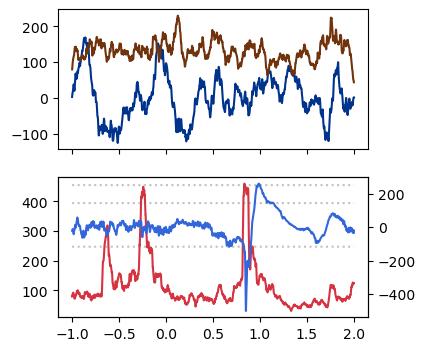

In [13]:
win = int(resrate/16)
rand_ERP = phase_scramble(ERP_mat, axes=-1)
rand_spikes = filtering.rolling_sum(np.abs(np.diff(rand_ERP,axis=-1)),win,axis=-1)
rand_t = rng.integers(low=0, high=ERP_mat.shape[0])

fig,[ax1,ax2] = plt.subplots(2,1,figsize=(4,4))
ax1.plot(plot_ts,rand_ERP[rand_t,:],c=[0,0.2,0.55])
ax1.plot(plot_ts[1:],rand_spikes[rand_t,:],c=[0.44,0.2,0.05])
ax2.plot(plot_ts,spike_mat[rand_t,:],c=[0.84,0.2,0.25])
ax2.plot(plot_ts, np.ones((len(plot_ts),1))*np.percentile(rand_spikes[:,1:].flatten(),[95,99,99.5]),":",c=[0.4,0.4,0.4,0.4])
ax3 = ax2.twinx()
ax3.plot(plot_ts,ERP_mat[rand_t,:],c=[0.2,0.4,0.85])
ax1.set_xticklabels("")
plt.show()

In [204]:
print(ERP_amps,np.mean(np.std(ERPs[:,plot_ts<-0.5].flatten())))

{np.str_('anger'): np.float64(53.50972129426576), np.str_('fear'): np.float64(41.464477573425754), np.str_('neutral'): np.float64(47.08972595394937), np.str_('happy'): np.float64(57.040375498346535), np.str_('house'): np.float64(49.543188598437226)} 7.974294264451767


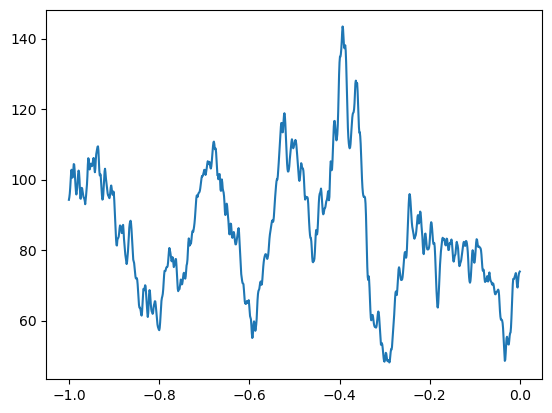

In [90]:
pixs = np.arange(resrate,resrate*2,1,dtype=int)
pixs = np.arange(0,resrate,1,dtype=int)
plt.plot(plot_ts[pixs],spike_mat[172,pixs])